In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPARATION

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
#SHAPE
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)  

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [58]:
#MISSING VALUES
print("\nMissing values (Trades):")
print(trades.isnull().sum()) 

print("\nMissing values (Sentiment):")
print(sentiment.isnull().sum())


Missing values (Trades):
account                  0
Coin                     0
Execution Price          0
Size Tokens              0
size                     0
side                     0
time                131999
Start Position           0
Direction                0
closedPnL                0
Transaction Hash         0
Order ID                 0
Crossed                  0
Fee                      0
Trade ID                 0
Timestamp                0
date                131999
dtype: int64

Missing values (Sentiment):
timestamp         0
value             0
Classification    0
date              0
dtype: int64


In [59]:
#DUPLICATES
print("\nDuplicate rows (Trades):", trades.duplicated().sum())
print("Duplicate rows (Sentiment):", sentiment.duplicated().sum())   


Duplicate rows (Trades): 0
Duplicate rows (Sentiment): 0


In [60]:
 #RENAME COLUMNS
trades = trades.rename(columns={
    'Account': 'account',
    'Closed PnL': 'closedPnL',
    'Size USD': 'size',
    'Side': 'side',
    'Timestamp IST': 'time'
})                                                  

sentiment = sentiment.rename(columns={
    'classification': 'Classification'     
})

In [61]:
# DATETIME CONVERSION
trades['time'] = pd.to_datetime(trades['time'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')     

In [62]:
# EXTRACT DATA
trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['date'].dt.date     

In [63]:
merged = pd.merge(trades, sentiment[['date','Classification']], on='date', how='inner')   # MERGE

In [64]:
# WIN RATE
merged['win'] = merged['closedPnL'] > 0    

In [65]:
# AVG TRADE SIZE
merged['trade_size'] = merged['size'].abs()   
merged['trade_size'].mean()                  

np.float64(4920.359087664511)

In [66]:
 # PROXY FOR LEVERAGE
merged['size_group'] = pd.cut(
    merged['trade_size'],
    bins=[0,1000,10000,1000000],
    labels=['Small','Medium','Large']      
)

In [67]:
# DAILY PnL
daily_pnl = merged.groupby(['account','date'])['closedPnL'].sum().reset_index()  

In [68]:
 # TRADES PER DAY
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')   

In [69]:
#LONG/SHORT RATIO
long_short = merged['side'].value_counts(normalize=True)
print(long_short)     

side
SELL    0.538172
BUY     0.461828
Name: proportion, dtype: float64


# ANALYSIS

## Performance Analysis

In [70]:
 # Drawdown proxy
drawdown = daily_pnl.groupby('account')['closedPnL'].min().reset_index()
drawdown.rename(columns={'closedPnL':'drawdown'}, inplace=True)
print(drawdown.head())                

                                      account       drawdown
0  0x083384f897ee0f19899168e3b1bec365f52a9012 -175611.000056
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   -3169.355468
2  0x271b280974205ca63b716753467d5a371de622ab     208.817460
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   -1416.906536
4  0x2c229d22b100a7beb69122eed721cee9b24011dd    -710.786946


In [71]:
merged = merged.drop(columns=['drawdown'], errors='ignore')

merged = merged.merge(drawdown, on='account', how='left')
print(merged.columns)

Index(['account', 'Coin', 'Execution Price', 'Size Tokens', 'size', 'side',
       'time', 'Start Position', 'Direction', 'closedPnL', 'Transaction Hash',
       'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date',
       'Classification', 'win', 'trade_size', 'size_group', 'drawdown'],
      dtype='object')


In [72]:
performance = merged.groupby('Classification').agg({
    'closedPnL':'mean',
    'win':'mean',
    'drawdown':'mean'
}).reset_index()

print(performance)

  Classification   closedPnL       win      drawdown
0   Extreme Fear    1.891632  0.292777 -10242.768670
1  Extreme Greed  205.816345  0.553282 -19411.652885
2           Fear  128.287950  0.381787 -37165.141487
3          Greed   53.988003  0.435707 -17530.065158
4        Neutral   27.088803  0.494920 -12209.085280


## Behavioral Analysis

In [73]:
freq = merged.groupby(['date','Classification']).size().reset_index(name='trade_count')

print(freq.groupby('Classification')['trade_count'].mean())

Classification
Extreme Fear     387.666667
Extreme Greed    130.720930
Fear             374.837838
Greed            201.642857
Neutral          172.250000
Name: trade_count, dtype: float64


In [74]:
size_behavior = merged.groupby('Classification')['trade_size'].mean().reset_index()
print(size_behavior)

  Classification   trade_size
0   Extreme Fear  4118.761840
1  Extreme Greed  3242.085086
2           Fear  5744.782685
3          Greed  5051.878829
4        Neutral  4332.202906


In [75]:
ls_sentiment = merged.groupby(['Classification','side']).size().reset_index(name='count')
print(ls_sentiment)

  Classification  side  count
0   Extreme Fear   BUY   1168
1   Extreme Fear  SELL   1158
2  Extreme Greed   BUY   1661
3  Extreme Greed  SELL   3960
4           Fear   BUY   7307
5           Fear  SELL   6562
6          Greed   BUY   5407
7          Greed  SELL   5885
8        Neutral   BUY   1020
9        Neutral  SELL   1736


In [76]:
risk_behavior = merged.groupby(['Classification','size_group']).size().reset_index(name='count')
print(risk_behavior)

   Classification size_group  count
0    Extreme Fear      Small   1453
1    Extreme Fear     Medium    663
2    Extreme Fear      Large    210
3   Extreme Greed      Small   3744
4   Extreme Greed     Medium   1425
5   Extreme Greed      Large    452
6            Fear      Small   8032
7            Fear     Medium   4386
8            Fear      Large   1440
9           Greed      Small   6499
10          Greed     Medium   3630
11          Greed      Large   1160
12        Neutral      Small   1826
13        Neutral     Medium    663
14        Neutral      Large    267


C:\Users\KRISHNA\AppData\Local\Temp\ipykernel_54660\3663853987.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_behavior = merged.groupby(['Classification','size_group']).size().reset_index(name='count')


## Segmentation

In [77]:
#HIGH vs LOW LEVERAGE(USING TARDE SIZE)
merged['size_group'] = pd.cut(
    merged['trade_size'],
    bins=[0,1000,10000,1000000],
    labels=['Low','Medium','High']    
)

segment_size = merged.groupby(['size_group','Classification'], observed=True)['closedPnL'].mean().reset_index()

print(segment_size)

   size_group Classification    closedPnL
0         Low   Extreme Fear     1.133160
1         Low  Extreme Greed    29.156397
2         Low           Fear     8.068616
3         Low          Greed     9.113657
4         Low        Neutral     5.418398
5      Medium   Extreme Fear     0.785170
6      Medium  Extreme Greed   257.383203
7      Medium           Fear    95.654196
8      Medium          Greed    75.503245
9      Medium        Neutral    40.158201
10       High   Extreme Fear    10.632795
11       High  Extreme Greed  1506.551020
12       High           Fear   904.443514
13       High          Greed   238.212151
14       High        Neutral   142.838427


In [78]:
 #FREQUENT vs INFREQUENT TRADERS
trader_activity = merged.groupby('account').size().reset_index(name='trade_count')

threshold = trader_activity['trade_count'].median()

trader_activity['frequency_type'] = np.where(
    trader_activity['trade_count'] > threshold,       
    'Frequent','Infrequent'
)

merged = merged.merge(trader_activity[['account','frequency_type']], on='account')


In [79]:
freq_segment = merged.groupby(['frequency_type','Classification'])['closedPnL'].mean().reset_index()

print(freq_segment)

  frequency_type Classification   closedPnL
0       Frequent   Extreme Fear    0.404794
1       Frequent  Extreme Greed  214.018191
2       Frequent           Fear  121.274107
3       Frequent          Greed   53.020310
4       Frequent        Neutral   27.066550
5     Infrequent   Extreme Fear   12.289279
6     Infrequent  Extreme Greed   59.828982
7     Infrequent           Fear  201.866477
8     Infrequent          Greed   73.255854
9     Infrequent        Neutral   29.110904


In [80]:
# CONSISTENT vs INCONSISTENT TRADERS
consistency = merged.groupby('account')['closedPnL'].std().reset_index()

threshold = consistency['closedPnL'].median()

consistency['consistency_type'] = np.where(
    consistency['closedPnL'] < threshold,            
    'Consistent','Inconsistent' 
)

merged = merged.merge(consistency[['account','consistency_type']], on='account')

In [81]:
consistency_segment = merged.groupby(['consistency_type','Classification'])['closedPnL'].mean().reset_index()

print(consistency_segment)

  consistency_type Classification   closedPnL
0       Consistent   Extreme Fear    6.061742
1       Consistent  Extreme Greed   23.817951
2       Consistent           Fear   14.799070
3       Consistent          Greed   17.861613
4       Consistent        Neutral   30.882479
5     Inconsistent   Extreme Fear    0.500002
6     Inconsistent  Extreme Greed  301.508769
7     Inconsistent           Fear  192.911244
8     Inconsistent          Greed   88.795224
9     Inconsistent        Neutral   25.048009


# INSIGHTS

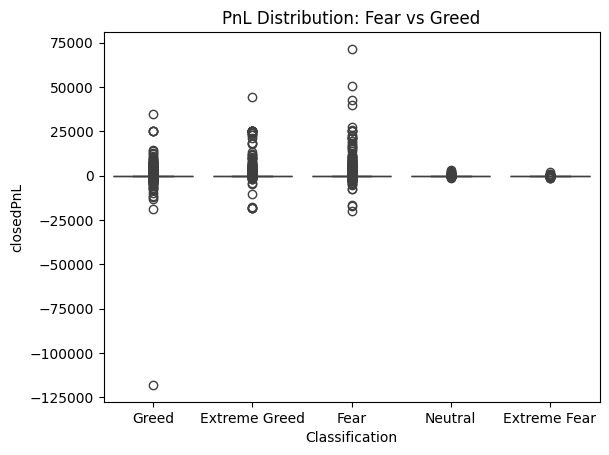

In [92]:
#PnL DISTRIBUTION
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Create folder automatically
os.makedirs("outputs/charts", exist_ok=True)

sns.boxplot(x='Classification', y='closedPnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")

plt.savefig(r"C:\Users\KRISHNA\OneDrive\Desktop\Trader-Sentiment-Analysis\Outputs\Charts\pnl_vs_sentiment.png")
plt.show()

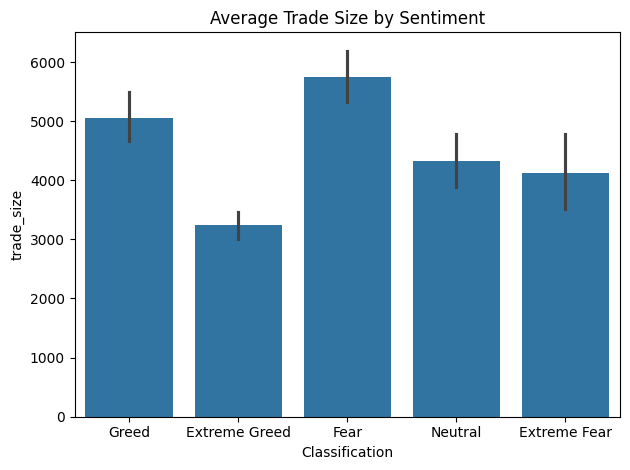

In [93]:
# TRADE SIZE BY SENTIMENT
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Classification', y='trade_size', data=merged)
plt.title("Average Trade Size by Sentiment")

plt.tight_layout()
plt.savefig(r"C:\Users\KRISHNA\OneDrive\Desktop\Trader-Sentiment-Analysis\Outputs\Charts\trade_size_by_sentiment.png")

plt.show()

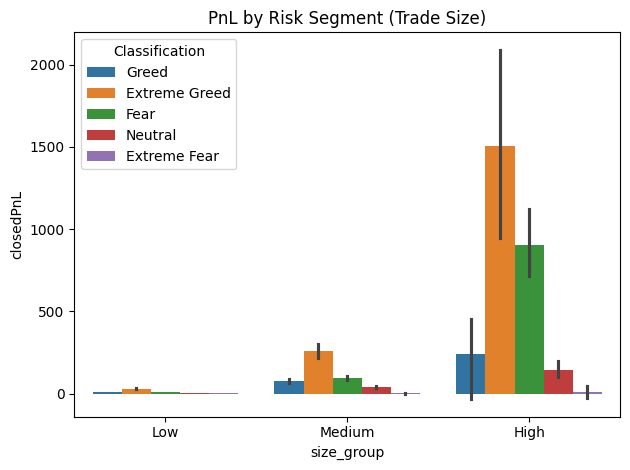

In [94]:
# SEGMENT ANALYSIS
sns.barplot(
    x='size_group',
    y='closedPnL',
    hue='Classification',
    data=merged
)

plt.title("PnL by Risk Segment (Trade Size)")

plt.tight_layout()
plt.savefig(r"C:\Users\KRISHNA\OneDrive\Desktop\Trader-Sentiment-Analysis\Outputs\Charts\segment_analysis.png")

plt.show()

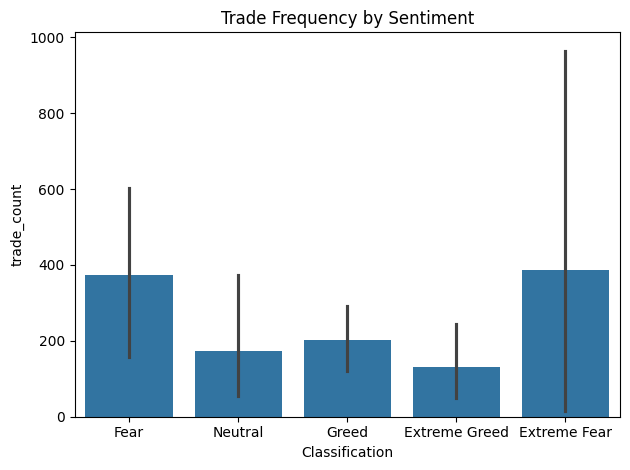

In [95]:
# TRADE FREQUENCY BY SENTIMENT
freq = merged.groupby(['date','Classification']).size().reset_index(name='trade_count')

sns.barplot(x='Classification', y='trade_count', data=freq)
plt.title("Trade Frequency by Sentiment")

plt.tight_layout()
plt.savefig(r"C:\Users\KRISHNA\OneDrive\Desktop\Trader-Sentiment-Analysis\Outputs\Charts\trade_frequency.png")

plt.show()

# PREDICTIVE MODEL

In [85]:
# Sort data
merged = merged.sort_values(['account','date'])

# Next day PnL
merged['next_pnl'] = merged.groupby('account')['closedPnL'].shift(-1)

# Target (classification)
merged['target'] = (merged['next_pnl'] > 0).astype(int)

In [86]:
features = merged[['trade_size','win','size']]
features = features.fillna(0)

target = merged['target'].fillna(0)

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Accuracy: 0.8788512477345601

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      4051
           1       0.86      0.86      0.86      3122

    accuracy                           0.88      7173
   macro avg       0.88      0.88      0.88      7173
weighted avg       0.88      0.88      0.88      7173



# 📄 Summary

## Methodology

The analysis began with cleaning and validating both datasets, including checking for missing values and duplicates. Timestamps were converted and aligned at a daily level to merge market sentiment data with trader activity. Key features were engineered, including daily PnL, win rate, trade size (used as a proxy for leverage), trade frequency, and drawdown (minimum daily PnL). Traders were further segmented based on risk level (trade size), trading frequency, and consistency of performance to enable deeper behavioral analysis.

## Key Insights

1. Traders achieve higher average PnL and win rates during **Greed** periods compared to Fear periods, indicating improved performance in bullish conditions.  
2. Trade sizes increase significantly during Greed, reflecting higher risk-taking behavior among traders.  
3. High-risk traders (large trade sizes) generate higher returns in Greed markets but suffer larger losses during Fear periods, highlighting asymmetric risk exposure.  
4. Frequent traders tend to perform well in Greed markets but often underperform during Fear periods due to overtrading in volatile conditions.  

## Strategy Recommendations

1. **Risk Reduction in Fear Markets:**  
   During Fear periods, traders should reduce position sizes and avoid high-risk trades, especially those with large exposure, to minimize downside risk.

2. **Selective Aggression in Greed Markets:**  
   During Greed periods, traders can increase trade frequency and position sizes, but this should be limited to consistent or high-performing traders to maximize gains while controlling risk.

3. **Control Overtrading Behavior:**  
   Frequent traders should moderate their activity during volatile Fear markets to avoid losses caused by excessive trading.